In [1]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

# Standard scientific Python imports
import matplotlib.pyplot as plt

# Import datasets, classifiers and performance metrics
from sklearn import datasets

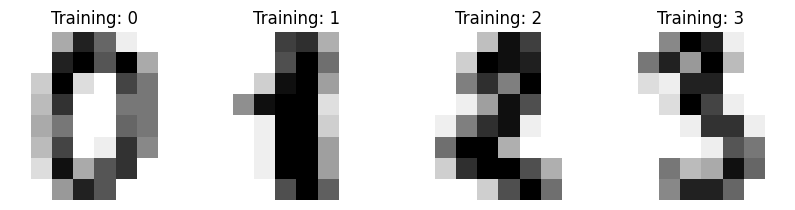

In [2]:
digits = datasets.load_digits()

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title("Training: %i" % label)

In [3]:
# Normalize the image to [0, 1] and flip pixels to 2-x with 50% probability

import numpy as np
import random

images = digits.images / 16.0
flip = np.random.rand(*images.shape) > 0.5
images = np.where(flip, 2 - images, images)


def plot_image(image):
    # Flip pixels back if value > 1
    image = np.where(image > 1, 2 - image, image)
    plt.imshow(image, cmap="gray_r")
    plt.axis("off")
    plt.show()

In [4]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import numpy as np
from jaxtyping import Array, Float
import matplotlib.pyplot as plt
from typing import Callable, Optional, Literal
from model import Flow, OscFlow, CNF
import jax.random as jr


jax.config.update("jax_enable_x64", True)

In [36]:
def loss(flow: Flow, t: Array, x_t: Array, dx_t: Array) -> Array:
    pred = jax.vmap(flow, in_axes=(0, 0))(t, x_t)
    l2 = optax.l2_loss(pred, dx_t)
    return l2.mean(), l2


def sample_data(
    x_1: Array,
    n_samples: int = 256,
    x_sample_fn: Callable = lambda shape: np.random.randn(*shape),
    t_sample_fn: Callable = lambda n: np.random.rand(n, 1),
) -> tuple[Array, Array, Array]:
    x_0 = jnp.array(x_sample_fn(x_1.shape))
    t = jnp.array(t_sample_fn(len(x_1)))

    x_t = (1 - t) * x_0 + t * x_1
    dx_t = x_1 - x_0

    return t.squeeze(), x_t, dx_t


def uniform_phase_sample(shape):
    return np.random.uniform(-0.5, 1.5, shape)


def train(
    flow: Flow,
    loss: Callable,
    dataset_fn: Callable,
    batch_size: int = 256,
    lr: float = 1e-3,
    n_iters: int = 10000,
    print_every: int = 1000,
    x_sample_fn: Callable = lambda shape: np.random.randn(*shape),
    t_sample_fn: Callable = lambda n: np.random.rand(n, 1),
):

    @eqx.filter_jit
    def step(
        flow: Flow, opt_state: optax.OptState, t: Array, x_t: Array, dx_t: Array
    ) -> Array:
        (loss_mean, _), grads = eqx.filter_value_and_grad(loss, has_aux=True)(
            flow, t, x_t, dx_t
        )
        updates, opt_state = optimizer.update(grads, opt_state)
        flow = eqx.apply_updates(flow, updates)
        return flow, opt_state, loss_mean

    optimizer = optax.adam(lr)
    opt_state = optimizer.init(eqx.filter(flow, eqx.is_array))
    dataloader = dataset_fn(batch_size)

    for iter, x_1 in zip(range(n_iters), dataloader):
        t, x_t, dx_t = sample_data(
            x_1,
            n_samples=batch_size,
            x_sample_fn=x_sample_fn,
            t_sample_fn=t_sample_fn,
        )

        flow, opt_state, loss_mean = step(flow, opt_state, t, x_t, dx_t)

        if iter % print_every == 0:
            print(f"Iter {iter}, Loss: {loss_mean}")
    return flow


def cnf_loss(cnf: CNF, data: Array, train_key: Array) -> Array:
    log_likelihood = jax.vmap(cnf.train)(data, key=train_key)
    return (
        -jnp.mean(log_likelihood),
        -log_likelihood,
    )  # minimise negative log-likelihood


def train_cnf(
    cnf: CNF,
    loss: Callable,
    dataset_fn: Callable,
    batch_size: int = 256,
    lr: float = 1e-3,
    n_iters: int = 10000,
    print_every: int = 1000,
    loss_key: Array = jr.PRNGKey(0),
):

    @eqx.filter_jit
    def step(cnf: CNF, opt_state: optax.OptState, x_1: Array, keys) -> Array:
        (loss_mean, _), grads = eqx.filter_value_and_grad(loss, has_aux=True)(
            cnf, x_1, keys
        )
        updates, opt_state = optimizer.update(grads, opt_state)
        cnf = eqx.apply_updates(cnf, updates)
        return cnf, opt_state, loss_mean

    # Set up optimizer with exponential learning rate decay

    optimizer = optax.adam(lr)
    opt_state = optimizer.init(eqx.filter(cnf, eqx.is_array))

    dataloader = dataset_fn(batch_size)
    loss_keys = jr.split(loss_key, n_iters)

    for iter, x_1_sample, key in zip(range(n_iters), dataloader, loss_keys):
        keys = jr.split(key, batch_size)

        cnf, opt_state, loss_mean = step(cnf, opt_state, x_1_sample, keys)

        if iter % print_every == 0:
            print(f"Iter {iter}, Loss: {loss_mean}")
    return cnf

In [ ]:
def plot_net_output(flow: OscFlow, n_steps: int = 20):
    time_points = jnp.linspace(0, 1.0, n_steps)
    cpl_w, lock_w, bias_w = [], [], []
    for t in time_points:
        cpl, lock, bias = flow.get_time_weights(t)
        cpl_w.append(cpl)
        lock_w.append(lock)
        bias_w.append(bias)

    # plot three weights
    cpl_w = jnp.stack(cpl_w, axis=0)
    lock_w = jnp.stack(lock_w, axis=0)
    bias_w = jnp.stack(bias_w, axis=0)

    figs, axes = plt.subplots(3, 1, figsize=(4, 6))
    axes[0].plot(time_points, cpl_w)
    axes[0].set_title("Coupling Weights over Time")
    axes[1].plot(time_points, lock_w)
    axes[1].set_title("Locking Weights over Time")
    axes[2].plot(time_points, bias_w)
    axes[2].set_title("Bias Weights over Time")
    plt.show()

In [7]:
def image_dataset(batch_size: int):
    # Enumerate over the dataset in batches
    # Restart and reshuffle from beginning when dataset is exhausted
    def dataloader():
        num_samples = images.shape[0]
        indices = np.arange(num_samples)
        while True:
            np.random.shuffle(indices)
            for start_idx in range(0, num_samples, batch_size):
                # Discard incomplete batch
                if start_idx + batch_size > num_samples:
                    break
                excerpt = indices[start_idx : start_idx + batch_size]
                yield jnp.array(images[excerpt].reshape(-1, 64))

    return dataloader()

In [11]:
image_h, image_w = images.shape[1:3]
n_pixels = image_h * image_w

flow = OscFlow(dim=n_pixels, key=jr.PRNGKey(2))

cnf = CNF(
    flow=flow,
    exact_logp=False,
)
cnf = train_cnf(
    cnf=cnf,
    loss=cnf_loss,
    dataset_fn=image_dataset,
    batch_size=256,
    lr=1e-3,
    n_iters=100,
    print_every=1,
    loss_key=jr.PRNGKey(2),
)

Iter 0, Loss: 152.79792631586656
Iter 1, Loss: 114.79695880376312
Iter 2, Loss: 95.34973775869767
Iter 3, Loss: 70.81453835323259
Iter 4, Loss: 54.88496059754584
Iter 5, Loss: 38.26373977901831
Iter 6, Loss: 27.349756079351742
Iter 7, Loss: 20.131698472803524
Iter 8, Loss: 12.645380482636021
Iter 9, Loss: 0.8916791057841863
Iter 10, Loss: -1.7340430830318772
Iter 11, Loss: -8.70833925274853
Iter 12, Loss: -15.173057779246438
Iter 13, Loss: -18.2752988740134
Iter 14, Loss: -24.387120651941313
Iter 15, Loss: -29.687690165208515
Iter 16, Loss: -32.98054730350115
Iter 17, Loss: -37.16824496018173
Iter 18, Loss: -39.42555271720831
Iter 19, Loss: -40.80177561685088
Iter 20, Loss: -43.55466362534856
Iter 21, Loss: -47.00475247065408
Iter 22, Loss: -49.36754528393382
Iter 23, Loss: -51.87268874897449
Iter 24, Loss: -54.403097966285465
Iter 25, Loss: -58.34239023821573
Iter 26, Loss: -59.05911493321261
Iter 27, Loss: -63.99810009639717
Iter 28, Loss: -64.44910196893127
Iter 29, Loss: -65.747402

In [12]:
import matplotlib.pyplot as plt
import diffrax


def visualize_sample(
    flow: Flow,
    key=jr.PRNGKey(0),
    n_samples: int = 1,
    t0: float = 0.0,
    t1: float = 1.0,
    dt0: float = 0.05,
):

    # Plot samples
    fig, ax = plt.subplots(3, n_samples, figsize=(n_samples * 2, 6))
    ys = jr.uniform(
        key,
        (
            n_samples,
            flow.dim,
        ),
    )
    orig_images = jnp.where(images > 1, 2 - images, images)
    for i, y in enumerate(ys):
        ax[0, i].imshow(y.reshape(image_h, image_w), cmap="gray_r")
        ax[0, i].axis("off")
        term = diffrax.ODETerm(lambda t, x, args: flow(t, x))
        solver = diffrax.Tsit5()
        sol = diffrax.diffeqsolve(term, solver, t0, t1, dt0, y)
        (y,) = sol.ys
        sample_image = y.reshape(image_h, image_w)
        # Map periodic values to [0, 2] and flip symmetric pixels to [0, 1]
        sample_image = sample_image % 2.0
        sample_image = jnp.where(sample_image > 1, 2 - sample_image, sample_image)

        ax[1, i].imshow(sample_image, cmap="gray_r")
        ax[1, i].axis("off")

        # find closest training image
        dists = jnp.linalg.norm(
            orig_images.reshape(orig_images.shape[0], -1) - y, axis=1
        )
        closest_idx = jnp.argmin(dists)
        ax[2, i].imshow(
            orig_images[closest_idx].reshape(image_h, image_w), cmap="gray_r"
        )
        ax[2, i].axis("off")

    # Add titles
    ax[0, 0].set_title("Sampled Noise", fontsize=16)
    ax[1, 0].set_title("Generated Image", fontsize=16)
    ax[2, 0].set_title("Closest Training Image", fontsize=16)

    plt.show()

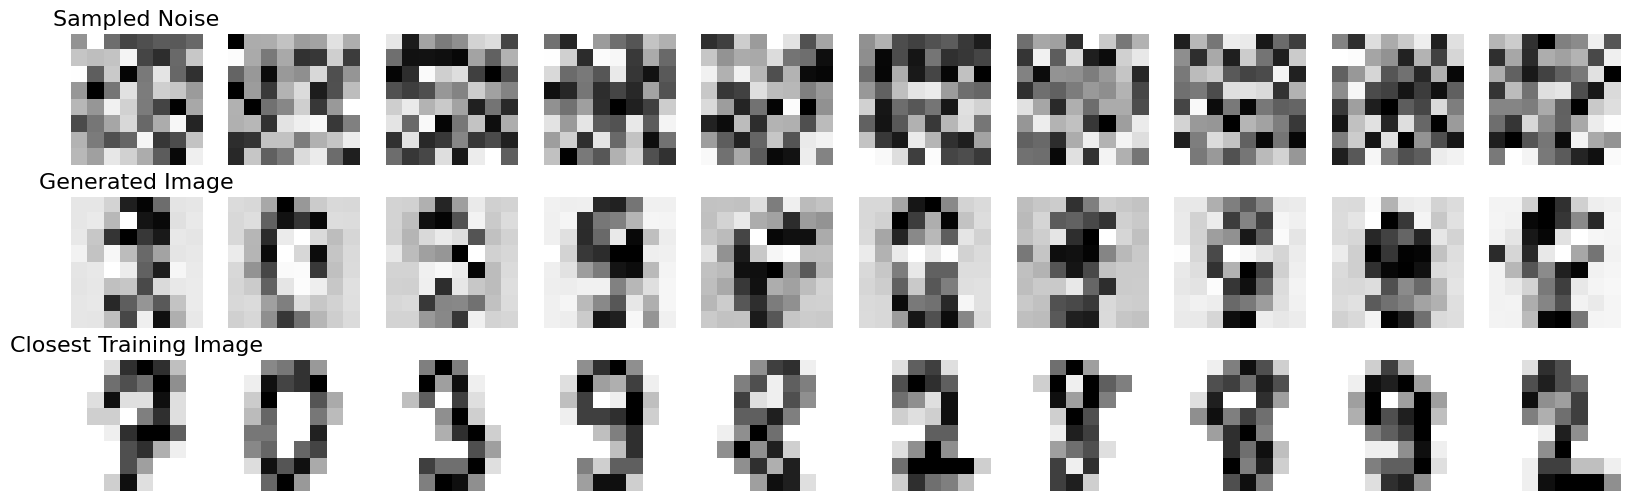

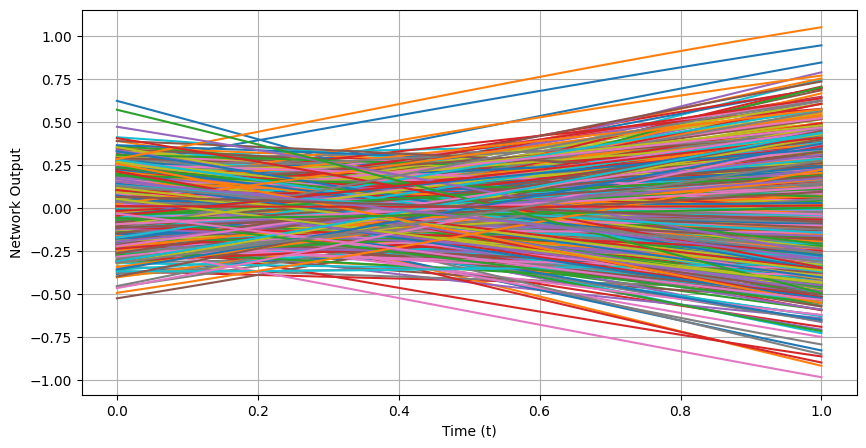

In [13]:
visualize_sample(cnf.flow, key=jr.PRNGKey(42), n_samples=10)
plot_net_output(cnf.flow, n_steps=100)

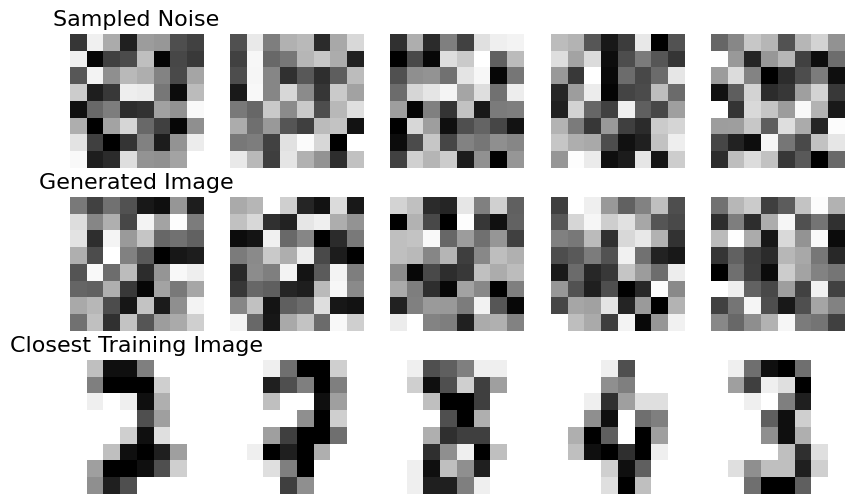

In [15]:
cnf_rand = CNF(
    flow=OscFlow(dim=n_pixels, key=jr.PRNGKey(3)),
    exact_logp=False,
)
visualize_sample(cnf_rand.flow, key=jr.PRNGKey(43), n_samples=5)

In [16]:
flow = Flow(dim=n_pixels, key=jr.PRNGKey(42))

flow = train(flow=flow, loss=loss, dataset_fn=image_dataset)

Iter 0, Loss: 1.3196746400606094
Iter 1000, Loss: 0.7397951172935777
Iter 2000, Loss: 0.6945736207478005
Iter 3000, Loss: 0.6728079528731004
Iter 4000, Loss: 0.6709326559913832
Iter 5000, Loss: 0.6570456835035385
Iter 6000, Loss: 0.6756686841310384
Iter 7000, Loss: 0.6727233961555865
Iter 8000, Loss: 0.6635365162346492
Iter 9000, Loss: 0.6577875225920389


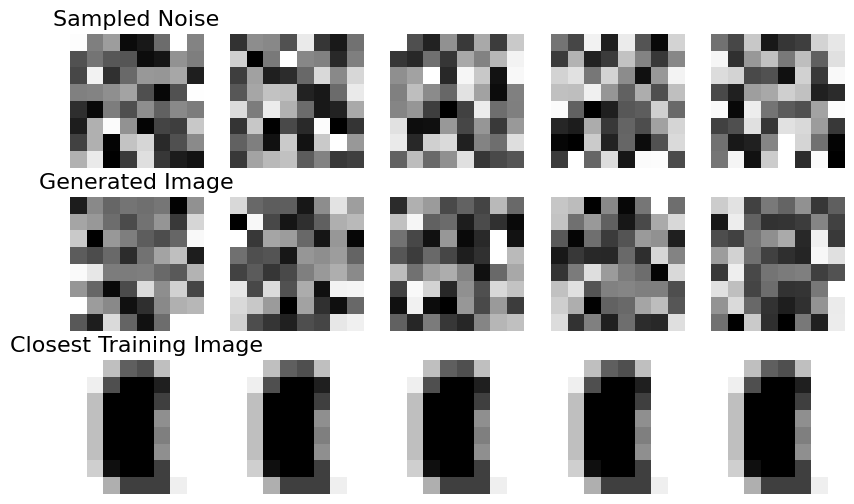

In [17]:
visualize_sample(flow=flow, key=jr.PRNGKey(44), n_samples=5)

In [18]:
flow = OscFlow(dim=n_pixels, key=jr.PRNGKey(2), n_phase_ref=10)

cnf_long = CNF(
    flow=flow,
    exact_logp=False,
    t0=0.0,
    t1=2.0,
    dt0=0.05,
)
cnf_long = train_cnf(
    cnf=cnf_long,
    loss=cnf_loss,
    dataset_fn=image_dataset,
    batch_size=256,
    lr=1e-3,
    n_iters=100,
    print_every=1,
    loss_key=jr.PRNGKey(2),
)

Iter 0, Loss: 509.127788975559
Iter 1, Loss: 420.65210450705365
Iter 2, Loss: 389.9550804719971
Iter 3, Loss: 371.65680551128435
Iter 4, Loss: 368.5837014870141
Iter 5, Loss: 357.19795180844807
Iter 6, Loss: 349.42232986286143
Iter 7, Loss: 342.9012605212116
Iter 8, Loss: 335.7859476270447
Iter 9, Loss: 323.2724964019051
Iter 10, Loss: 316.017491131873
Iter 11, Loss: 305.33977068064036
Iter 12, Loss: 305.1081336212953
Iter 13, Loss: 294.1007384982629
Iter 14, Loss: 288.3744400009866
Iter 15, Loss: 280.06033542368596
Iter 16, Loss: 273.0370556608664
Iter 17, Loss: 273.8708149005298
Iter 18, Loss: 270.64019052962925
Iter 19, Loss: 262.1985012868455
Iter 20, Loss: 255.5720795814672
Iter 21, Loss: 242.8003736800243
Iter 22, Loss: 230.3212059041921
Iter 23, Loss: 233.77078564419423
Iter 24, Loss: 226.6048657620103
Iter 25, Loss: 216.14055868158084
Iter 26, Loss: 209.2103358626001
Iter 27, Loss: 204.11771843902588
Iter 28, Loss: 195.71459587128675
Iter 29, Loss: 189.14886124410535
Iter 30, L

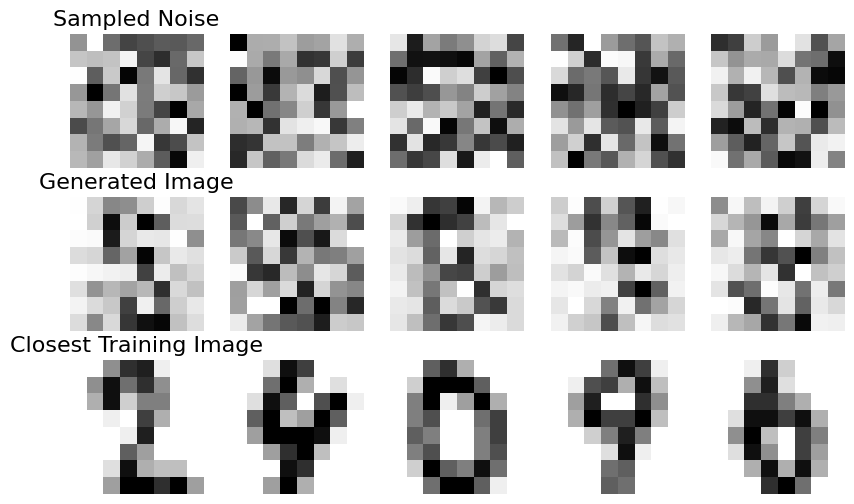

In [19]:
visualize_sample(cnf_long.flow, key=jr.PRNGKey(42), n_samples=5, t1=2.0)

In [27]:
image_h, image_w = images.shape[1:3]
n_pixels = image_h * image_w

flow = OscFlow(dim=n_pixels, key=jr.PRNGKey(666))

cnf = CNF(
    flow=flow,
    exact_logp=False,
)
cnf = train_cnf(
    cnf=cnf,
    loss=cnf_loss,
    dataset_fn=image_dataset,
    batch_size=256,
    lr=1e-2,
    n_iters=200,
    print_every=1,
    loss_key=jr.PRNGKey(777),
)

Iter 0, Loss: 146.07008508736277
Iter 1, Loss: 100.9740955914119
Iter 2, Loss: 71.73948757914309
Iter 3, Loss: 52.10904226068378
Iter 4, Loss: 36.25152955341258
Iter 5, Loss: 23.187538193681366
Iter 6, Loss: 10.893703305734295
Iter 7, Loss: 1.841727459647475
Iter 8, Loss: -5.778213096997462
Iter 9, Loss: -12.268223909900769
Iter 10, Loss: -18.728911564711993
Iter 11, Loss: -22.338833195391814
Iter 12, Loss: -27.28026178824067
Iter 13, Loss: -31.912916467883523
Iter 14, Loss: -35.00680053796862
Iter 15, Loss: -37.15562262783018
Iter 16, Loss: -42.7514790921856
Iter 17, Loss: -44.842839437907564
Iter 18, Loss: -46.85251113058696
Iter 19, Loss: -50.361918672481906
Iter 20, Loss: -54.55584164452576
Iter 21, Loss: -57.9472749351474
Iter 22, Loss: -60.4800441484405
Iter 23, Loss: -62.91486171600284
Iter 24, Loss: -64.55860620888797
Iter 25, Loss: -65.44138554080769
Iter 26, Loss: -68.04475084605986
Iter 27, Loss: -69.36137188695423
Iter 28, Loss: -71.5238685041449
Iter 29, Loss: -74.43654887

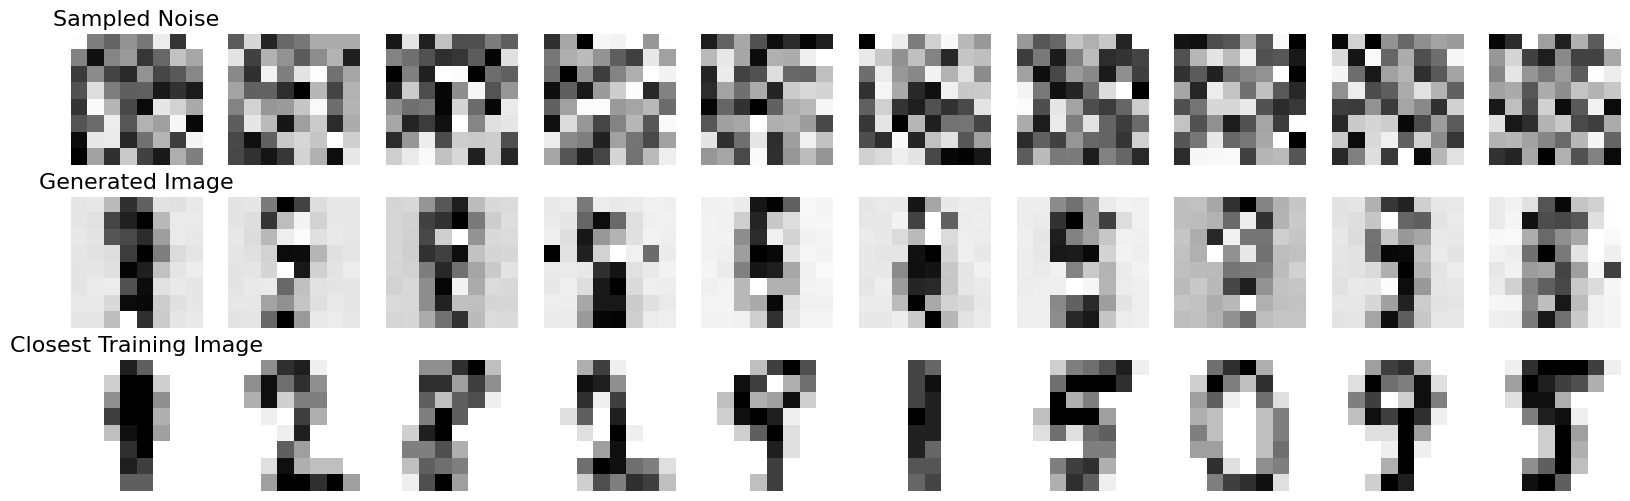

ValueError: x and y can be no greater than 2D, but have shapes (100,) and (100, 64, 66)

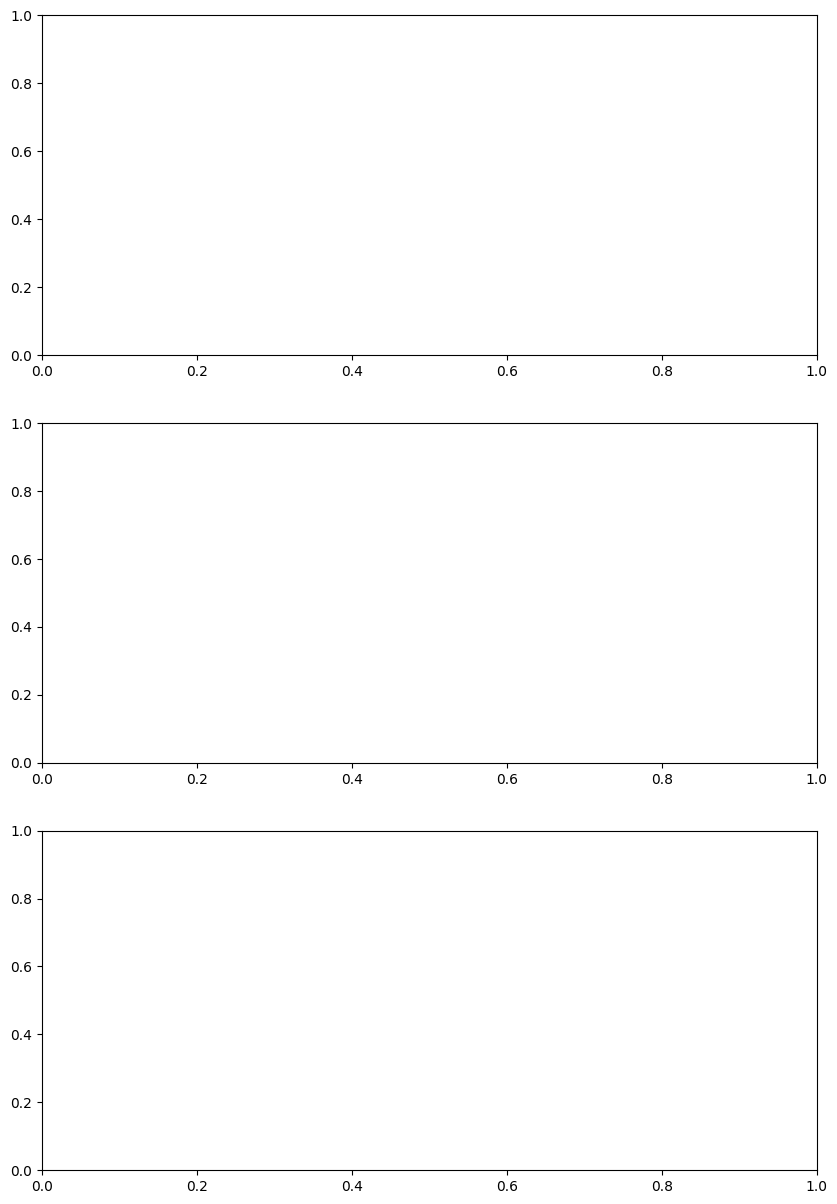

In [41]:
visualize_sample(cnf.flow, key=jr.PRNGKey(87), n_samples=10)
plot_net_output(cnf.flow, n_steps=100)

In [37]:
image_h, image_w = images.shape[1:3]
n_pixels = image_h * image_w

flow = OscFlow(dim=n_pixels, key=jr.PRNGKey(666))

cnf2 = CNF(
    flow=flow,
    exact_logp=False,
)
cnf2 = train_cnf(
    cnf=cnf2,
    loss=cnf_loss,
    dataset_fn=image_dataset,
    batch_size=256,
    lr=1e-3,
    n_iters=200,
    print_every=1,
    loss_key=jr.PRNGKey(667),
)

Iter 0, Loss: 148.25295283836329
Iter 1, Loss: 103.76150387108244
Iter 2, Loss: 75.65257915953734
Iter 3, Loss: 54.73078922062941
Iter 4, Loss: 40.941451235310794
Iter 5, Loss: 26.669785465864692
Iter 6, Loss: 18.952368620732923
Iter 7, Loss: 6.851704667037517
Iter 8, Loss: -3.426730039403306
Iter 9, Loss: -10.615975429272542
Iter 10, Loss: -17.98925868190244
Iter 11, Loss: -20.120809608389706
Iter 12, Loss: -24.86223468087541
Iter 13, Loss: -26.247216845997126
Iter 14, Loss: -31.66127518038462
Iter 15, Loss: -33.92383612118814
Iter 16, Loss: -41.2393952598927
Iter 17, Loss: -43.40550899736226
Iter 18, Loss: -46.79236234052084
Iter 19, Loss: -49.69068911687183
Iter 20, Loss: -48.48517781482038
Iter 21, Loss: -56.51132944257823
Iter 22, Loss: -58.961883435456116
Iter 23, Loss: -56.516758405151684
Iter 24, Loss: -63.560836233549026
Iter 25, Loss: -64.31753751712941
Iter 26, Loss: -64.92766072575733
Iter 27, Loss: -66.15215172259948
Iter 28, Loss: -69.71604790120556
Iter 29, Loss: -71.273

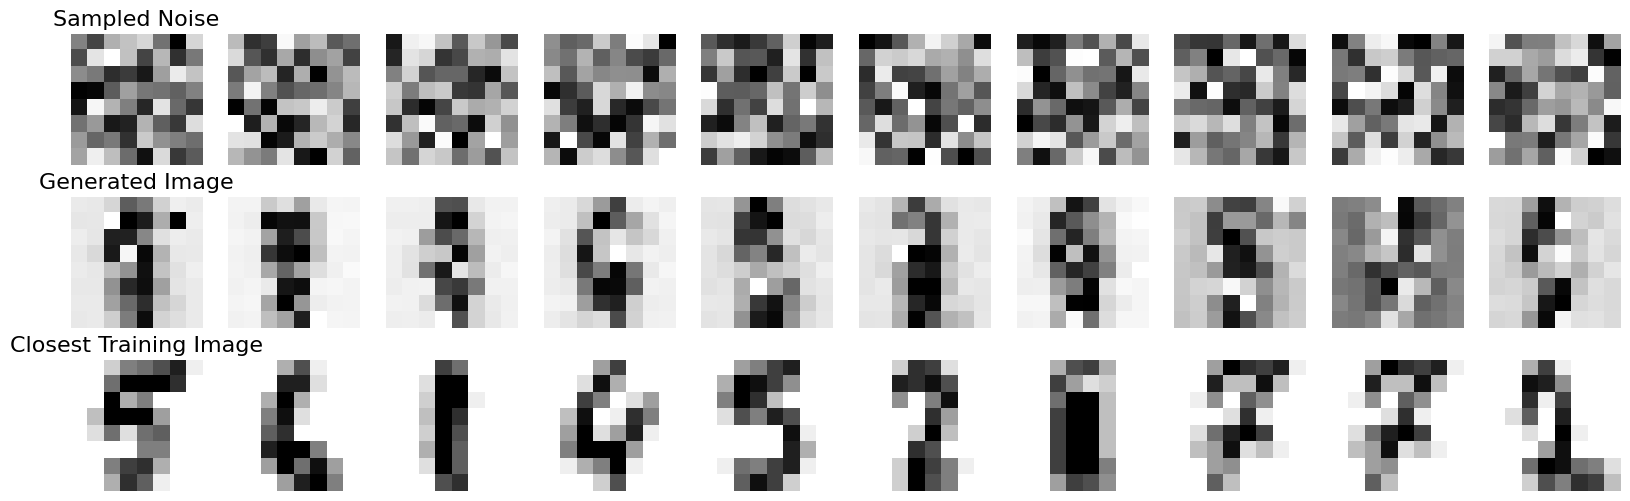

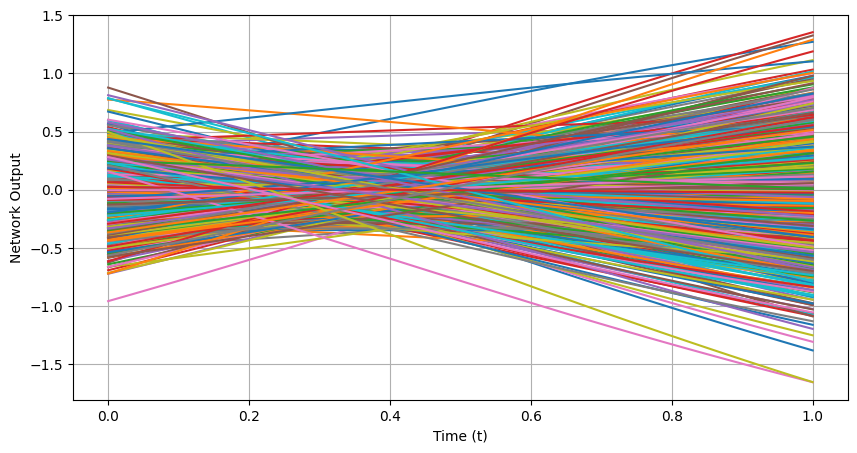

In [39]:
visualize_sample(cnf2.flow, key=jr.PRNGKey(234), n_samples=10)
plot_net_output(cnf2.flow, n_steps=100)